# HotpotQA Knowledge Network Demo

This notebook is the **full HotpotQA-specific knowledge-network demo path** for the GKN repo.

It compares:
- embedding baseline retrieval
- embedding + HotpotQA-specific KN retrieval

Unlike the earlier benchmark scaffold, this notebook uses a dedicated HotpotQA graph design with:
- title entities
- named entities
- supporting-fact nodes
- graph path explanations
- reusable and reproducible vector-store caching


## 1. Methodology overview

This benchmark follows the same overall philosophy as the synthetic-document KN demo, but adapts the graph structure to the HotpotQA use case.

### What makes this KN benchmark-specific?

HotpotQA is a multi-hop benchmark where questions often require bridging across multiple articles. Therefore, the graph for this use case focuses on:

- article titles as graph anchors
- named entities as bridge nodes
- supporting-fact nodes as evaluation-aware anchors
- graph-expanded chunk retrieval
- path explanations for interpretability

### What is being compared?

1. **Embedding baseline retrieval**
2. **Embedding retrieval + HotpotQA-specific knowledge network**

### What counts as relevance here?

For the current version, relevance is approximated by mapping supporting titles to normalized document IDs and then treating chunks from those documents as relevant chunks. This is still a coarse approximation, but it is a much better benchmark setting than the synthetic demo alone.

## 2. Setup and configuration

This step loads your local configuration from `.env`, prepares artifact folders, and prints the active benchmark settings.

### Reproducibility notes

This workflow is designed to be reproducible:
- the HotpotQA subset is selected using a fixed random seed
- the vector store cache key includes sample size, random seed, embedding choice, model, and chunk signature
- if the same sample selection and corpus are used again, the vector store should be loaded from cache rather than rebuilt

### Recommended first-run settings

- `HOTPOTQA_SAMPLE_SIZE=25`
- `EMBEDDING_CHOICE=local` for initial debugging
- then switch to `small` or `large` for benchmark-quality reruns
- set `FORCE_REBUILD_VECTOR_STORE=false` unless you intentionally want a rebuild


In [1]:
from pathlib import Path
import sys
import pandas as pd

sys.path.append(str(Path.cwd().parent / 'src'))

from geometric_knowledge_network.config import GKNConfig
from geometric_knowledge_network.hotpotqa_benchmark import HotpotBenchmarkRunner
from geometric_knowledge_network.hotpotqa_graph import HotpotEntityExtractor, HotpotGraphBuilder
from geometric_knowledge_network.hotpotqa_loader import HotpotQALoader
from geometric_knowledge_network.hybrid_retriever import HybridRetriever
from geometric_knowledge_network.path_explainer import GraphPathExplainer
from geometric_knowledge_network.reporting import ArtifactManager
from geometric_knowledge_network.vector_store import EmbeddingVectorStore
from geometric_knowledge_network.visualization import draw_subgraph

config = GKNConfig()
artifacts = ArtifactManager(config.artifacts_dir)
run_id = artifacts.timestamp()

def status(message: str):
    print(f'[DONE] {message}')

status(f'Configuration loaded. Run ID: {run_id}')
print('HotpotQA path:', config.hotpotqa_data_path)
print('Path exists:', Path(config.hotpotqa_data_path).exists())
print('Sample size:', config.hotpotqa_sample_size)
print('Random seed:', config.hotpotqa_random_seed)
print('Embedding choice:', config.embedding_choice)
print('Embedding model:', config.openai_embedding_model if config.embedding_choice != 'local' else config.local_embedding_model)
print('Force rebuild vector store:', config.force_rebuild_vector_store)
print('Checkpoints dir:', config.checkpoints_dir)
print('Base URL set:', bool(config.openai_base_url))
print('API key set:', bool(config.openai_api_key))

[DONE] Configuration loaded. Run ID: 20260622_140540
HotpotQA path: C:\Users\minwuu01\GKN\data\hotpot_train_v1.1.json
Path exists: True
Sample size: 999
Random seed: 42
Embedding choice: small
Embedding model: text-embedding-3-small
Force rebuild vector store: False
Checkpoints dir: C:\Users\minwuu01\GKN\checkpoints
Base URL set: True
API key set: True


## 3. Load HotpotQA sample and construct retrieval units

This step converts sampled HotpotQA contexts into document and chunk units suitable for both vector retrieval and graph construction.

### Why this matters

The same chunk corpus is used by:
- the embedding baseline
- the HotpotQA-specific knowledge network
- the retrieval benchmark evaluation

This is important for fairness: both retrievers operate over the same underlying retrieval units.

In [2]:
loader = HotpotQALoader()
documents, chunks, samples = loader.load_samples(
    config.hotpotqa_data_path,
    sample_size=config.hotpotqa_sample_size,
    random_seed=config.hotpotqa_random_seed,
)
status(f'Loaded {len(samples)} HotpotQA samples, {len(documents)} documents, and {len(chunks)} chunks.')

for sample in samples[:3]:
    print('-' * 100)
    print('Question ID:', sample.question_id)
    print('Question:', sample.question)
    print('Answer:', sample.answer)
    print('Supporting titles:', sample.supporting_titles)

[DONE] Loaded 999 HotpotQA samples, 9750 documents, and 20754 chunks.
----------------------------------------------------------------------------------------------------
Question ID: 5a7bb1315542997c3ec97253
Question: Which Emmett's Mark actor also played in the HBO series "The Wire"?
Answer: John Doman
Supporting titles: ["Emmett's Mark", 'John Doman']
----------------------------------------------------------------------------------------------------
Question ID: 5ae03a3655429942ec259c50
Question: Who directed the upcoming British action comedy film which has Johnny English as the first part? 
Answer: David Kerr
Supporting titles: ['Johnny English (film series)', 'Johnny English 3']
----------------------------------------------------------------------------------------------------
Question ID: 5ab77e6655429928e1fe385d
Question: What conference has the most valuable NBA franchise according to Forbes?
Answer: Western Conference
Supporting titles: ['2008 NBA Playoffs', 'Los Angeles La

## 4. Build or load the embedding vector store

This step either:
- loads a previously built vector store from cache, or
- builds a new one and saves it for reuse

### Why this matters

The HotpotQA benchmark should be reusable and reproducible. If you rerun the notebook with the same:
- sample size
- random seed
- embedding mode
- embedding model
- chunk corpus

then the vector store should be reused automatically rather than rebuilt.

If you hit rate limits in cloud embedding mode, this cached reuse becomes especially important.

In [3]:
vector_store = EmbeddingVectorStore(config)
vector_store.build(chunks)
status('Embedding vector store ready (built or loaded from cache).')

[INFO] Loading cached vector store from C:\Users\minwuu01\GKN\checkpoints\hotpotqa_vs_small_999_42_27e0fd208369.pkl
[DONE] Embedding vector store ready (built or loaded from cache).


## 5. Build the HotpotQA-specific knowledge network

This step builds the graph structure used by the KN-enhanced retriever.

### Graph design for HotpotQA

The graph includes:
- document nodes
- chunk nodes
- title entity nodes
- named entity nodes
- supporting-fact nodes
- concept nodes

This differs from the governance demo because the benchmark structure is different: HotpotQA is about multi-hop article/entity bridging, not requirement-control logic.

In [4]:
extractor = HotpotEntityExtractor()
graph = HotpotGraphBuilder(extractor).build(documents, chunks, samples)
status(f'HotpotQA knowledge network built with {graph.number_of_nodes()} nodes and {graph.number_of_edges()} edges.')

node_type_counts = pd.Series([graph.nodes[node].get('node_type', 'Unknown') for node in graph.nodes]).value_counts().reset_index()
node_type_counts.columns = ['node_type', 'count']
display(node_type_counts)

[DONE] HotpotQA knowledge network built with 82783 nodes and 192167 edges.


,node_type,count
0,NamedEntity,40091
1,Chunk,20754
2,TitleEntity,9767
3,Document,9750
4,SupportingFact,2409
5,Concept,12


## 6. Evaluate baseline vs KN-enhanced retrieval

This step runs the benchmark comparison.

### What is being measured?

For each HotpotQA question, we compare:
- baseline embedding retrieval
- embedding retrieval + HotpotQA-specific KN augmentation

and compute retrieval metrics such as:
- hit rate
- recall@k
- precision@k
- MRR

We also capture path explanations when graph expansion adds results.

In [5]:
hybrid = HybridRetriever(vector_store, graph)
path_explainer = GraphPathExplainer(graph)
benchmark = HotpotBenchmarkRunner(vector_store, hybrid, chunks, path_explainer)
benchmark_result = benchmark.run(samples, top_k=config.top_k, graph_hops=config.graph_hops)
status(f'Completed HotpotQA KN benchmark for {len(samples)} questions.')

evaluation_df = benchmark_result.evaluation_df
aggregate_df = benchmark_result.aggregate_df
paths_df = benchmark_result.paths_df

display(evaluation_df.head())
display(aggregate_df)
display(paths_df.head())

[DONE] Completed HotpotQA KN benchmark for 999 questions.


,question_id,question,category,retriever,hit_rate,recall_at_k,precision_at_k,mrr
0,5a7bb1315542997c3ec97253,Which Emmett's Mark actor also played in the H...,hotpotqa,baseline,1.0,0.500000,0.333333,1.000000
1,5a7bb1315542997c3ec97253,Which Emmett's Mark actor also played in the H...,hotpotqa,hybrid,1.0,0.500000,0.333333,0.333333
2,5ae03a3655429942ec259c50,Who directed the upcoming British action comed...,hotpotqa,baseline,1.0,0.666667,0.666667,1.000000
3,5ae03a3655429942ec259c50,Who directed the upcoming British action comed...,hotpotqa,hybrid,1.0,0.666667,0.666667,0.500000
4,5ab77e6655429928e1fe385d,What conference has the most valuable NBA fran...,hotpotqa,baseline,1.0,0.250000,0.333333,0.333333


,retriever,hit_rate,recall_at_k,precision_at_k,mrr
0,baseline,0.950951,0.572575,0.573574,0.904404
1,hybrid,0.950951,0.572992,0.574241,0.787287


,question_id,question,seed_chunk_id,target_chunk_id,path_exists,hop_count,edge_types,path_labels
0,5a712cf85542994082a3e627,What synthetic stimulant is sometimes called f...,methcathinone_chunk_0,methcathinone_chunk_1_0,True,2,CONTAINS | CONTAINS,methcathinone_chunk_0 | Methcathinone | methca...
1,5a83dbc25542992ef85e237d,"In which year, did this earliest guest star in...",list_of_spongebob_squarepants_guest_stars_chun...,list_of_spongebob_squarepants_guest_stars_chunk_0,True,2,CONTAINS | CONTAINS,list_of_spongebob_squarepants_guest_stars_chun...
2,5a7b6e2255429927d897bfcd,"The album that had ""One"" by Irish rock band U2...",all_that_you_can't_leave_behind_chunk_1_0,all_that_you_can't_leave_behind_chunk_1_1,True,2,CONTAINS | CONTAINS,all_that_you_can't_leave_behind_chunk_1_0 | Al...
3,5ab2c72755429916697740c5,"Which plant species, Emmenopterys or Olea, is ...",olea_oleaster_chunk_1_0,olea_oleaster_chunk_0,True,2,CONTAINS | CONTAINS,olea_oleaster_chunk_1_0 | Olea oleaster | olea...
4,5a8bc28e5542995d1e6f1445,What nationality is the manager who left Chels...,list_of_rosenborg_bk_managers_chunk_1_0,list_of_rosenborg_bk_managers_chunk_0,True,2,CONTAINS | CONTAINS,list_of_rosenborg_bk_managers_chunk_1_0 | List...


## 7. Inspect retrieval examples and graph-path explanations

This step helps interpret how the KN behaves on individual examples.

For the first few examples, we want to inspect:
- the question
- the supporting titles
- baseline retrieval metrics
- hybrid retrieval metrics
- whether graph-expanded paths were used


In [6]:
for sample in samples[:3]:
    print('=' * 100)
    print('Question ID:', sample.question_id)
    print('Question:', sample.question)
    print('Supporting titles:', sample.supporting_titles)
    sample_rows = evaluation_df[evaluation_df['question_id'] == sample.question_id]
    display(sample_rows)
    sample_paths = paths_df[paths_df['question_id'] == sample.question_id]
    if not sample_paths.empty:
        print('Graph-expanded paths:')
        display(sample_paths)
    else:
        print('No graph-expanded paths recorded for this example.')

Question ID: 5a7bb1315542997c3ec97253
Question: Which Emmett's Mark actor also played in the HBO series "The Wire"?
Supporting titles: ["Emmett's Mark", 'John Doman']


,question_id,question,category,retriever,hit_rate,recall_at_k,precision_at_k,mrr
0,5a7bb1315542997c3ec97253,Which Emmett's Mark actor also played in the H...,hotpotqa,baseline,1.0,0.5,0.333333,1.000000
1,5a7bb1315542997c3ec97253,Which Emmett's Mark actor also played in the H...,hotpotqa,hybrid,1.0,0.5,0.333333,0.333333


No graph-expanded paths recorded for this example.
Question ID: 5ae03a3655429942ec259c50
Question: Who directed the upcoming British action comedy film which has Johnny English as the first part? 
Supporting titles: ['Johnny English (film series)', 'Johnny English 3']


,question_id,question,category,retriever,hit_rate,recall_at_k,precision_at_k,mrr
2,5ae03a3655429942ec259c50,Who directed the upcoming British action comed...,hotpotqa,baseline,1.0,0.666667,0.666667,1.0
3,5ae03a3655429942ec259c50,Who directed the upcoming British action comed...,hotpotqa,hybrid,1.0,0.666667,0.666667,0.5


No graph-expanded paths recorded for this example.
Question ID: 5ab77e6655429928e1fe385d
Question: What conference has the most valuable NBA franchise according to Forbes?
Supporting titles: ['2008 NBA Playoffs', 'Los Angeles Lakers']


,question_id,question,category,retriever,hit_rate,recall_at_k,precision_at_k,mrr
4,5ab77e6655429928e1fe385d,What conference has the most valuable NBA fran...,hotpotqa,baseline,1.0,0.25,0.333333,0.333333
5,5ab77e6655429928e1fe385d,What conference has the most valuable NBA fran...,hotpotqa,hybrid,1.0,0.25,0.333333,0.500000


No graph-expanded paths recorded for this example.


## 8. Visualize the knowledge network locally

This step renders a local subgraph around one chunk so you can inspect how the benchmark-specific KN is structured.

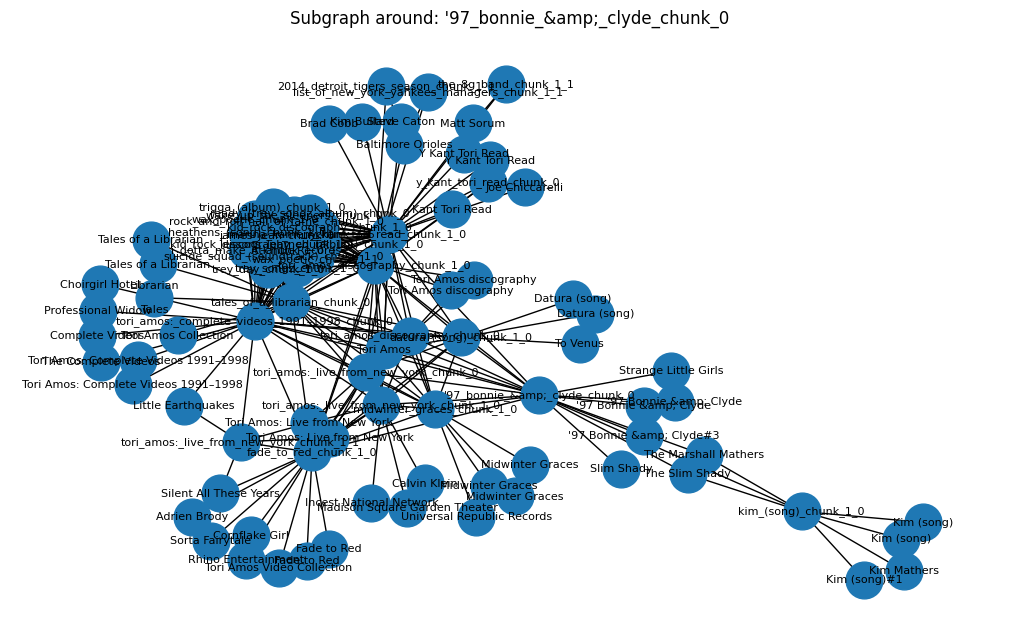

[DONE] HotpotQA KN subgraph rendered and saved to C:\Users\minwuu01\GKN\artifacts\figures\hotpotqa_kn_subgraph_20260622_140540.png


In [7]:
center_chunk_id = chunks[0].chunk_id if chunks else None
if center_chunk_id:
    figure_path = artifacts.figures_dir / f'hotpotqa_kn_subgraph_{run_id}.png'
    draw_subgraph(graph, center_chunk_id, radius=2, save_path=figure_path)
    status(f'HotpotQA KN subgraph rendered and saved to {figure_path}')
else:
    print('No chunks available for graph visualization.')

## 9. Save benchmark artifacts

This step saves:
- query-level retrieval metrics
- aggregate retrieval metrics
- graph-path explanation outputs
- graph summary


In [8]:
query_level_path = artifacts.save_dataframe(evaluation_df, f'hotpotqa_kn_query_level_{run_id}.csv')
aggregate_path = artifacts.save_dataframe(aggregate_df, f'hotpotqa_kn_aggregate_{run_id}.csv')
paths_path = artifacts.save_dataframe(paths_df, f'hotpotqa_kn_paths_{run_id}.csv')
graph_summary_path = artifacts.save_graph_summary(graph, f'hotpotqa_kn_graph_summary_{run_id}.json')

status(f'Saved HotpotQA KN query-level results to {query_level_path}')
status(f'Saved HotpotQA KN aggregate results to {aggregate_path}')
status(f'Saved path explanations to {paths_path}')
status(f'Saved graph summary to {graph_summary_path}')

[DONE] Saved HotpotQA KN query-level results to C:\Users\minwuu01\GKN\artifacts\reports\hotpotqa_kn_query_level_20260622_140540.csv
[DONE] Saved HotpotQA KN aggregate results to C:\Users\minwuu01\GKN\artifacts\reports\hotpotqa_kn_aggregate_20260622_140540.csv
[DONE] Saved path explanations to C:\Users\minwuu01\GKN\artifacts\reports\hotpotqa_kn_paths_20260622_140540.csv
[DONE] Saved graph summary to C:\Users\minwuu01\GKN\artifacts\graph\hotpotqa_kn_graph_summary_20260622_140540.json


## 10. Interpretation notes

When interpreting the results, keep in mind:

- the vector baseline and KN-enhanced retrieval use the same chunk corpus
- the HotpotQA-specific graph is benchmark-oriented, not governance-oriented
- relevance is still approximated at the supporting-title-to-chunk level
- future improvements can include sentence-level supporting-fact relevance and more query-aware graph scoring


## 11. Final note

This notebook is the **HotpotQA-specific KN demo path** for the repo.

Suggested progression:
- `HOTPOTQA_SAMPLE_SIZE=25` for first validation
- `HOTPOTQA_SAMPLE_SIZE=50` for a stronger smoke benchmark
- `HOTPOTQA_SAMPLE_SIZE=100` or more for a more meaningful public comparison run

Suggested embedding progression:
- `EMBEDDING_CHOICE=local` for fast debugging and zero API quota risk
- `EMBEDDING_CHOICE=small` for cloud benchmark runs
- `EMBEDDING_CHOICE=large` only when higher-quality embeddings are worth the extra cost/quota

If you reuse the same sample size, seed, chunk corpus, and embedding setup, the vector store should be loaded from cache automatically.